# Using FinBERT to classify 3M+ Tweets sentiment

We first load, examine and clean our data Tweet data. We merge ```Tweet.csv``` with ```Company_Tweet.csv``` in order to obtain ticker data per tweet, without duplicata. We optimize this process using vectorization.

In [ ]:
import pandas as pd
import warnings

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=SyntaxWarning)

df_tweets = pd.read_csv("data/Tweet/Tweet.csv")
df_ticker = pd.read_csv("data/Tweet/Company_Tweet.csv")

df_ticker['ticker'] = df_ticker['ticker'].astype(str) + ', '
df_ticker_agg = df_ticker.groupby('tweet_id', as_index=False).sum()
df_ticker_agg['ticker'] = df_ticker_agg['ticker'].str.rstrip(', ')

df = pd.merge(df_tweets, df_ticker_agg, on='tweet_id', how='left')
dates = pd.to_datetime(df['post_date'], unit='s')

print(f"Total tweets: {len(df)}")

Total tweets: 3717964


Our dataset contains 3,717,964 tweets: it is necessary to clean this mass of data entries.

Many of these tweets are irrelevant to current financial market conditions and use the $Cashtags system solely for advertising purposing. Examples include: 
- Give your brain a workout with Squares – Challenging Puzzle Game http://dlvr.it/7zTvGm #AppAdvice $AAPL
- Swing Trading: Up To 8.91% Return In 14 Days http://ow.ly/GDkrZ #swingtrading #forecast #techstock $MWW $AAPL $TSLA
- S&P100 #Stocks Performance $HD $LOW $SBUX $TGT $DVN $IBM $AMZN $F $APA $GM $MS $HAL $DIS $MCD $BMY $XOM  more@ http://12Stocks.com/sp100
- $UNP $ORCL $QCOM $MSFT $AAPL Top scoring mega caps right now at the end of 2014 on http://GetAOM.com
- http://BiloSelhi.com subscribers alerted to 10-250% gain options. JOIN NOW $QQQ $AAPL 
- Free course - Capital usage with Options http://bit.ly/CapiEffi $GLD $SLV $TSLA
- Algo Trading: Up to 61.09% Return In 1 Year http://ow.ly/GVxVm #tech #stocks $AAPL $TSLA
- #toptickertweets $AAPL $SPDC $SPY $TSLA $CLDN $YELP $TWTR $FB $FXE $EWG #sentiquant 20150427 18:00:04:186
- THE BINARY OPTIONS COMPETITION WIN $100,000 http://rbn.cm/VbMIHH $LNKD $AAPL $GOOGL $GOOLD #bones #options #forex #forextrading #Bonus

We should remove these tweets from our dataset: they don't carry relevant information for markets and are purely noise.

Hence, we filter out: 
- Advertisements detected with suspicious keywords
- Tweets including over 3+ stock tickers: they seek visibility instead of providing relevant information reflecting market sentiment

To facilitate finBERT sentiment analysis and limit tweet length, we also delete from all URLs textual content (they can sometimes be lenghty and go over our token limit). After this, our heaviest tweet went from 809 to 202 tokens.

In [2]:
# Removing tweets with spam keywords
keywords = ["JOIN NOW", "subscriber", "#AppAdvice", "Free course", "free course",
            "Free courses", "Competition", "free trial", "sign up", "How to use",
            "join our", "Join our", "Sign up", "Hope I win this #iPad", "#patent",
            "In 14 days", "Algo Trading", "Algorithmic Trading", "Cutting-edge course",
            "Premium Package", "Stock Picking by Algorithms", "Top 10 Stock Picks",
            "AI-Based Algorithms", "#Stocks Trend", "#Stocks Performance", "12Stocks.com",
            "ow.ly", "SUBSCRIBE", "subscribers", "#howtotrade", "monthly income",
            "COMPETITION", "FREE COURSE", "FREE COURSES", "FREE TRIAL", "SIGN UP",
            "#iDownloadBlog", "Five Easy Ways", "Free guide", "Free guides", "Free eBook",
            "Free eBooks", "stock content, charts, analysis, & more", "Screen through high rated",
            "Know the real risks in your positions", "Trading Strategies that work", "for FREE",
            "Chart of the Day", "Premium Picks", "For a Limited Time", "Make sure to use my link!",
            "Join @RobinhoodApp", "Join Robinhood App", "Free stocks app", "Free options app",
            "Highest scoring stories for #SP500 under one watchlist", "Having 10 different news tabs",
            "63-day volatility", "21-day volatility", "63-day Expected", "21-day Expected",
            "Stay ahead with", "See why these assets are trending", "Last 6H average sentiment"]

spam_pattern = "|".join(keywords)
df_spam = df[~df['body'].str.contains(spam_pattern, case=True, na=False)]
print(f"{len(df)-len(df_spam)} tweets removed after spam-keywords cleaning")

# Remove tweets with more than 4 cashtags
cashtag_regex = r'\$[a-zA-Z]{2,4}(?=\s|,|$)'
ticker_count = df['body'].str.findall(cashtag_regex).str.len()
df_cashtag = df[ticker_count <= 3].copy()
print(f"{len(df)-len(df_cashtag)} tweets removed after cashtag filtering")

df = pd.merge(df_spam, df_cashtag, how='inner')
df = df.reset_index(drop=True)

# Removing lengthy links (http://, https://, www.) from the body of the tweets
df['body'] = df['body'].str.replace(r'https?://\S+|(?:\w+\.)+\w+/\S*', '', regex=True)

dates = pd.to_datetime(df['post_date'], unit='s')


212480 tweets removed after spam-keywords cleaning
654260 tweets removed after cashtag filtering


We then compute basic descriptive metrics of the global datasets, as well as metrics regarding individual stocks.

In [ ]:
# Metrics
print(f"Total tweets: {len(df)}")
print(f"Earliest tweet: {dates.min()}")
print(f"Latest tweet: {dates.max()}")

companies = {"AAPL": "AAPL", "GOOGL": "GOOG", "AMZN": "AMZN", "TSLA": "TSLA", "MSFT": "MSFT"}
stats_d = []
stats_w = []

for name, ticker in companies.items():
    sub_df = df[df['ticker'].str.contains(ticker, na=False)]

    counts_daily = sub_df.groupby(dates.dt.date).size()
    counts_weekly = sub_df.groupby(dates.dt.to_period('W')).size()

    stats_d.append({"Company": name, "Mean": counts_daily.mean(), "Median": counts_daily.median(), "Std": counts_daily.std(), "Min": counts_daily.min(), "Max": counts_daily.max()})
    stats_w.append({"Company": name, "Mean": counts_weekly.mean(), "Median": counts_weekly.median(), "Std": counts_weekly.std(), "Min": counts_weekly.min(), "Max": counts_weekly.max()})

total_daily = df.groupby(dates.dt.date).size()
total_weekly = df.groupby(dates.dt.to_period('W')).size()

stats_d.append({"Company": "Total", "Mean": total_daily.mean(), "Median": total_daily.median(),"Std": total_daily.std(), "Min": total_daily.min(), "Max": total_daily.max()})
stats_w.append({"Company": "Total", "Mean": total_weekly.mean(), "Median": total_weekly.median(),"Std": total_weekly.std(), "Min": total_weekly.min(), "Max": total_weekly.max()})

print(f"\nDaily {pd.DataFrame(stats_d).set_index('Company').rename_axis(None).round(2)}")
print(f"\nWeekly {pd.DataFrame(stats_w).set_index('Company').rename_axis(None).round(2)}")

Total tweets: 2906577
Earliest tweet: 2015-01-01 00:01:36
Latest tweet: 2019-12-31 23:55:37

Daily           Mean  Median     Std  Min   Max
AAPL    539.96   371.0  533.25    4  4814
GOOGL   234.37   173.0  198.32   18  2009
AMZN    256.83   219.5  222.39    3  3746
TSLA    490.32   298.5  540.83    8  6167
MSFT    138.38    95.0  137.44    5  2670
Total  1591.77  1466.5  944.90  146  7079

Weekly            Mean   Median      Std   Min    Max
AAPL    3748.80   3151.5  2506.86   883  15656
GOOGL   1633.43   1304.5   971.42   183   5556
AMZN    1789.99   1662.5   775.83   303   5785
TSLA    3417.26   2093.5  2947.48   356  17473
MSFT     964.40    696.0   652.05   179   5997
Total  11093.81  10717.5  3737.22  2340  23777


Our tweet datasets extends over 5 years (2015-2019), covering 2,906,577 tweets. There are 1545 tweets per day on average, ranging from 156 to 7274 per day. This minimum indicates no missing days in our dataset. On a weekly basis, there are on average 11356 tweets.

The dataset covers 5 companies: Apple ($AAPL), Google ($GOOG and $GOOGL), Amazon ($AMZN), Tesla Inc. ($TSLA) and Microsoft ($MSFT). Apple is by far the most mentioned company, altough, Tesla surpasses it in both daily and weekly maximum mentions. 

Plotting these tweets frequencies allow us to grasp the distribution of tweets over time, both on a company basis and global basis.

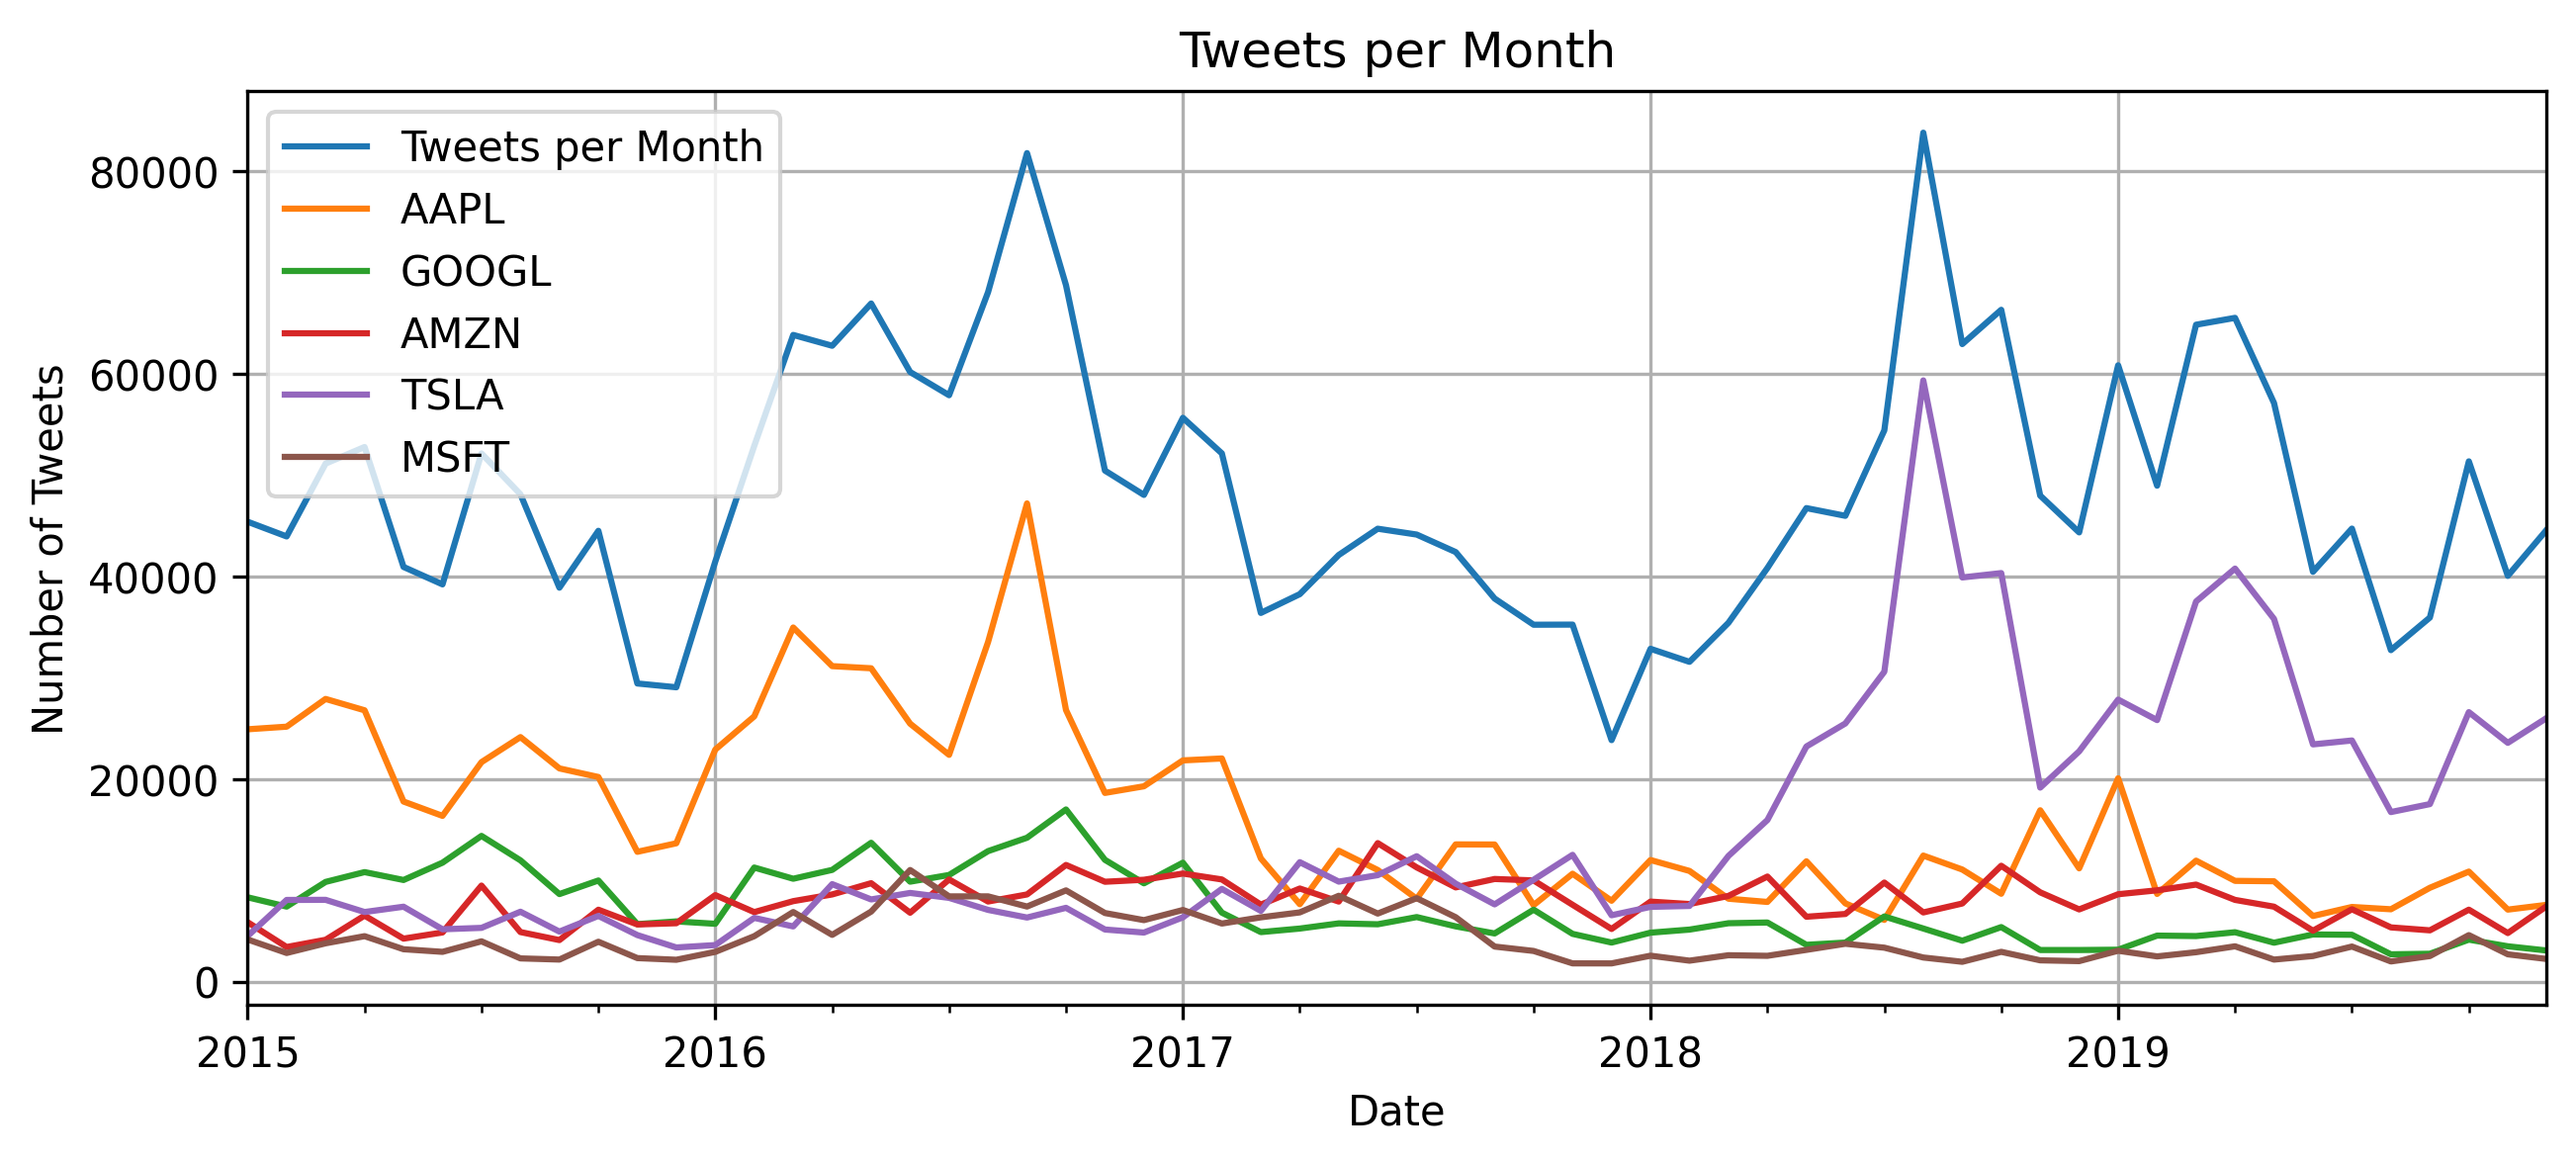

In [ ]:
import matplotlib.pyplot as plt

#plt.figure(figsize=(10, 4), dpi=300)
#
#total_daily.plot(label="Tweets per Day")
#
#for name, ticker in companies.items():
#    sub_df = df[df['ticker'].str.contains(ticker, na=False)]
#    counts_daily = sub_df.groupby(dates.dt.date).size()
#    counts_daily.plot(label=name)
#
#plt.title("Tweets per Day")
#plt.xlabel("Date")
#plt.ylabel("Number of Tweets")
#plt.grid()
#plt.legend(loc='upper left')
#plt.show()
#
#
#plt.figure(figsize=(10, 4), dpi=300)
#
#total_weekly.plot(label="Tweets per week")
#
#for name, ticker in companies.items():
#    sub_df = df[df['ticker'].str.contains(ticker, na=False)]
#    counts_weekly = sub_df.groupby(dates.dt.to_period('W')).size()
#    counts_weekly.plot(label=name)
#
#plt.title("Tweets per Week")
#plt.xlabel("Date")
#plt.ylabel("Number of Tweets")
#plt.grid()
#plt.legend(loc='upper left')
#plt.show()


plt.figure(figsize=(10, 4), dpi=300)

total_monthly = df.groupby(dates.dt.to_period('M')).size()
total_monthly.plot(label="Tweets per Month")

for name, ticker in companies.items():
    sub_df = df[df['ticker'].str.contains(ticker, na=False)]
    counts_monthly = sub_df.groupby(dates.dt.to_period('M')).size()
    counts_monthly.plot(label=name)

plt.title("Tweets per Month")
plt.xlabel("Date")
plt.ylabel("Number of Tweets")
plt.grid()
plt.legend(loc='upper left')
plt.show()

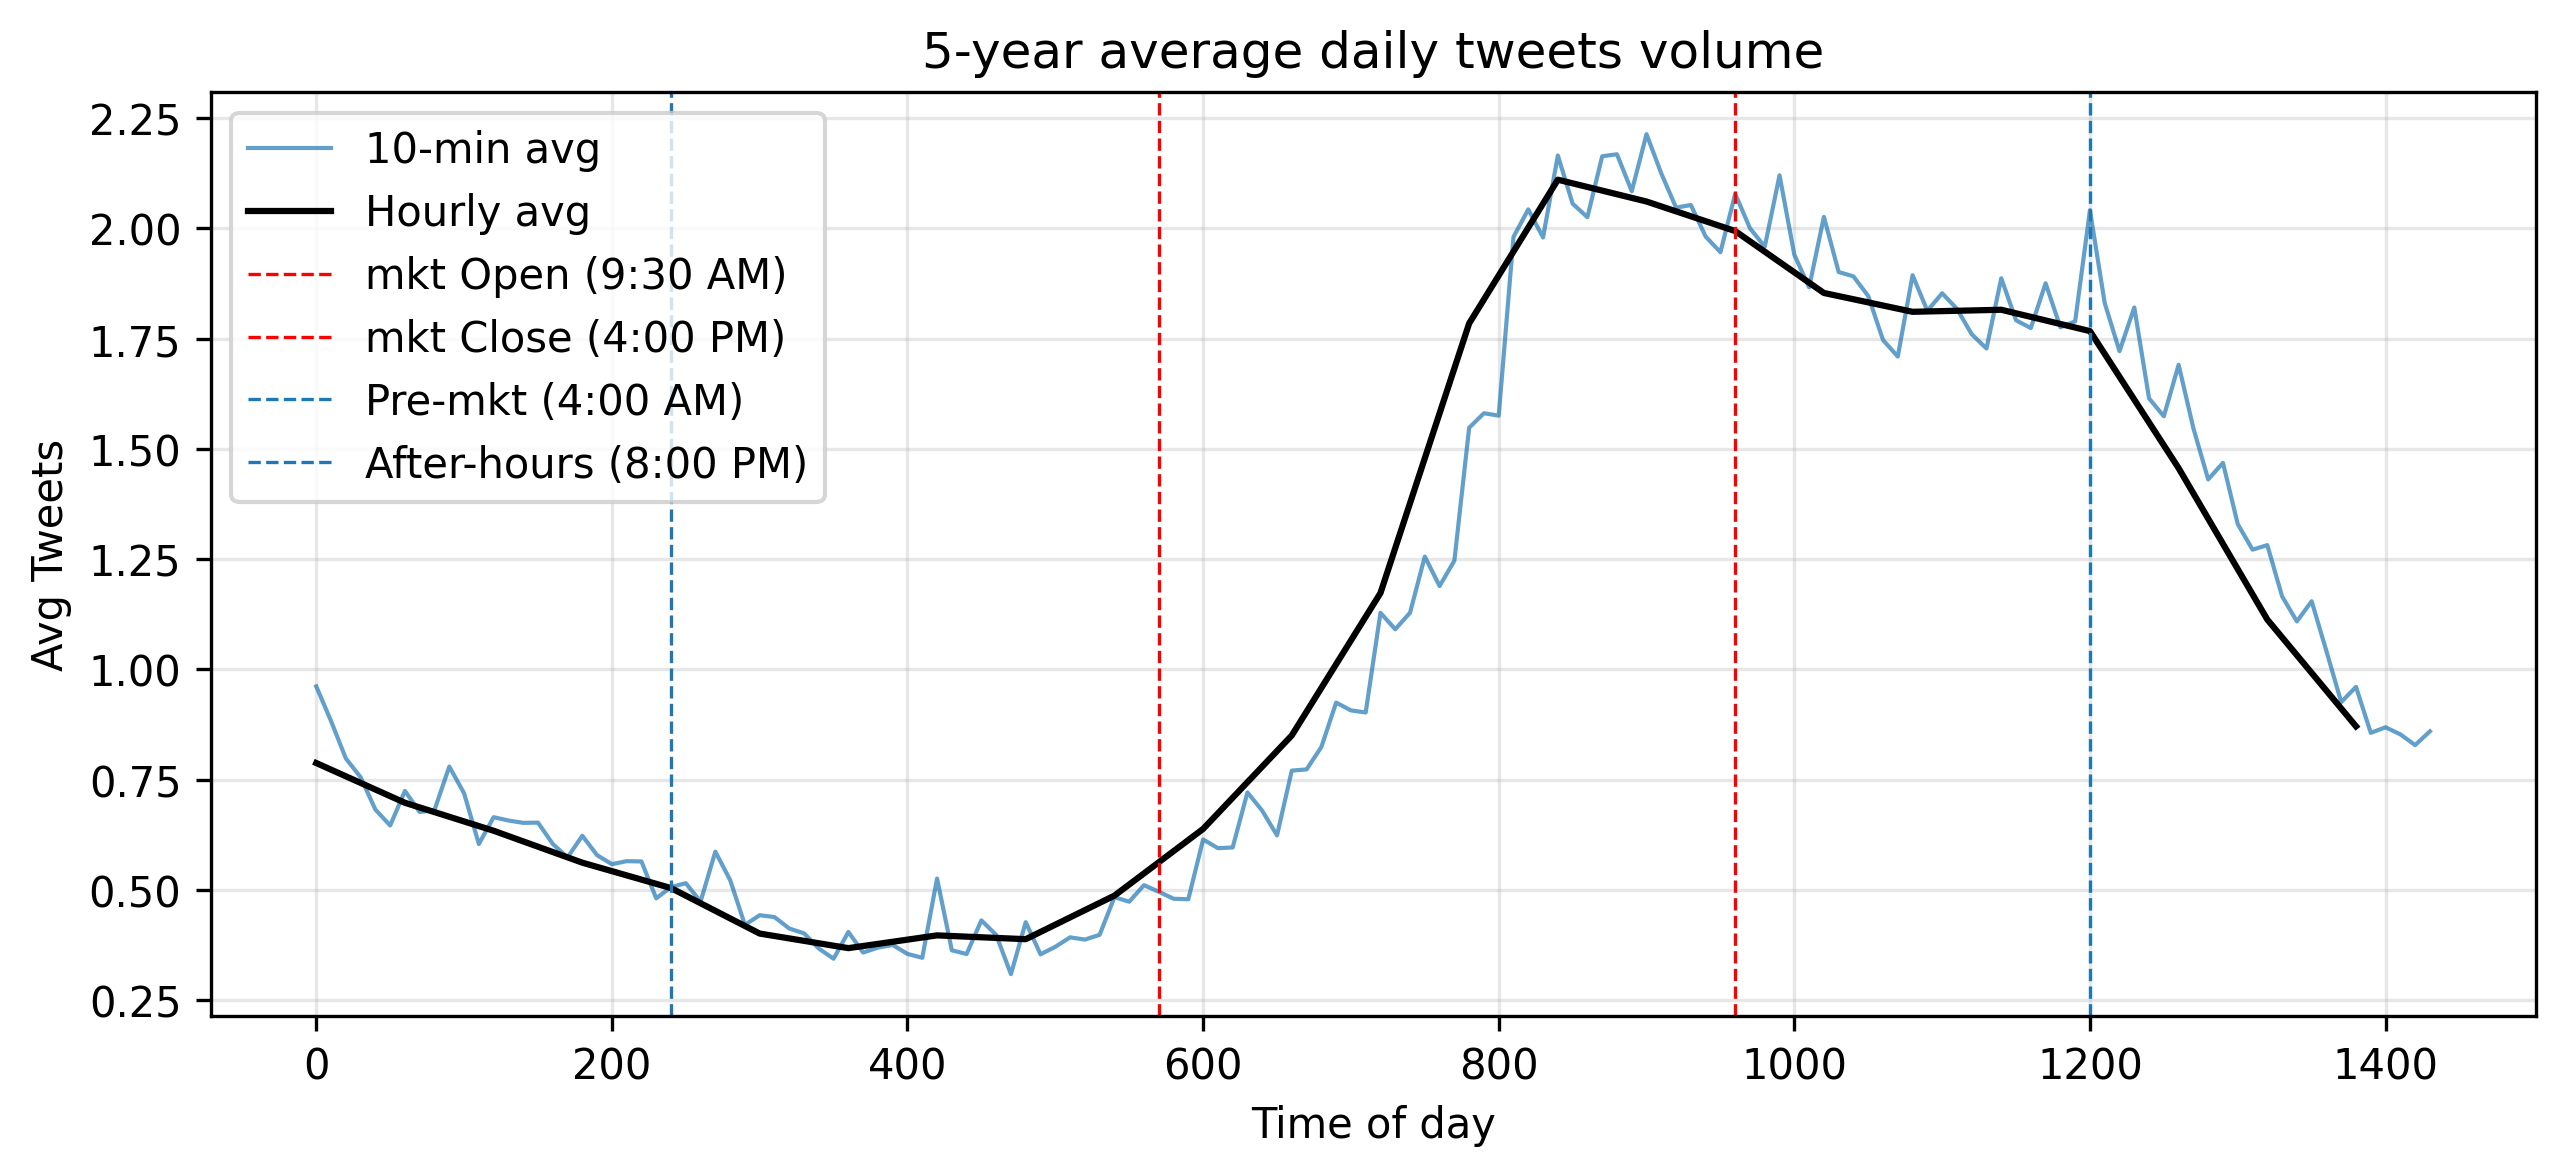

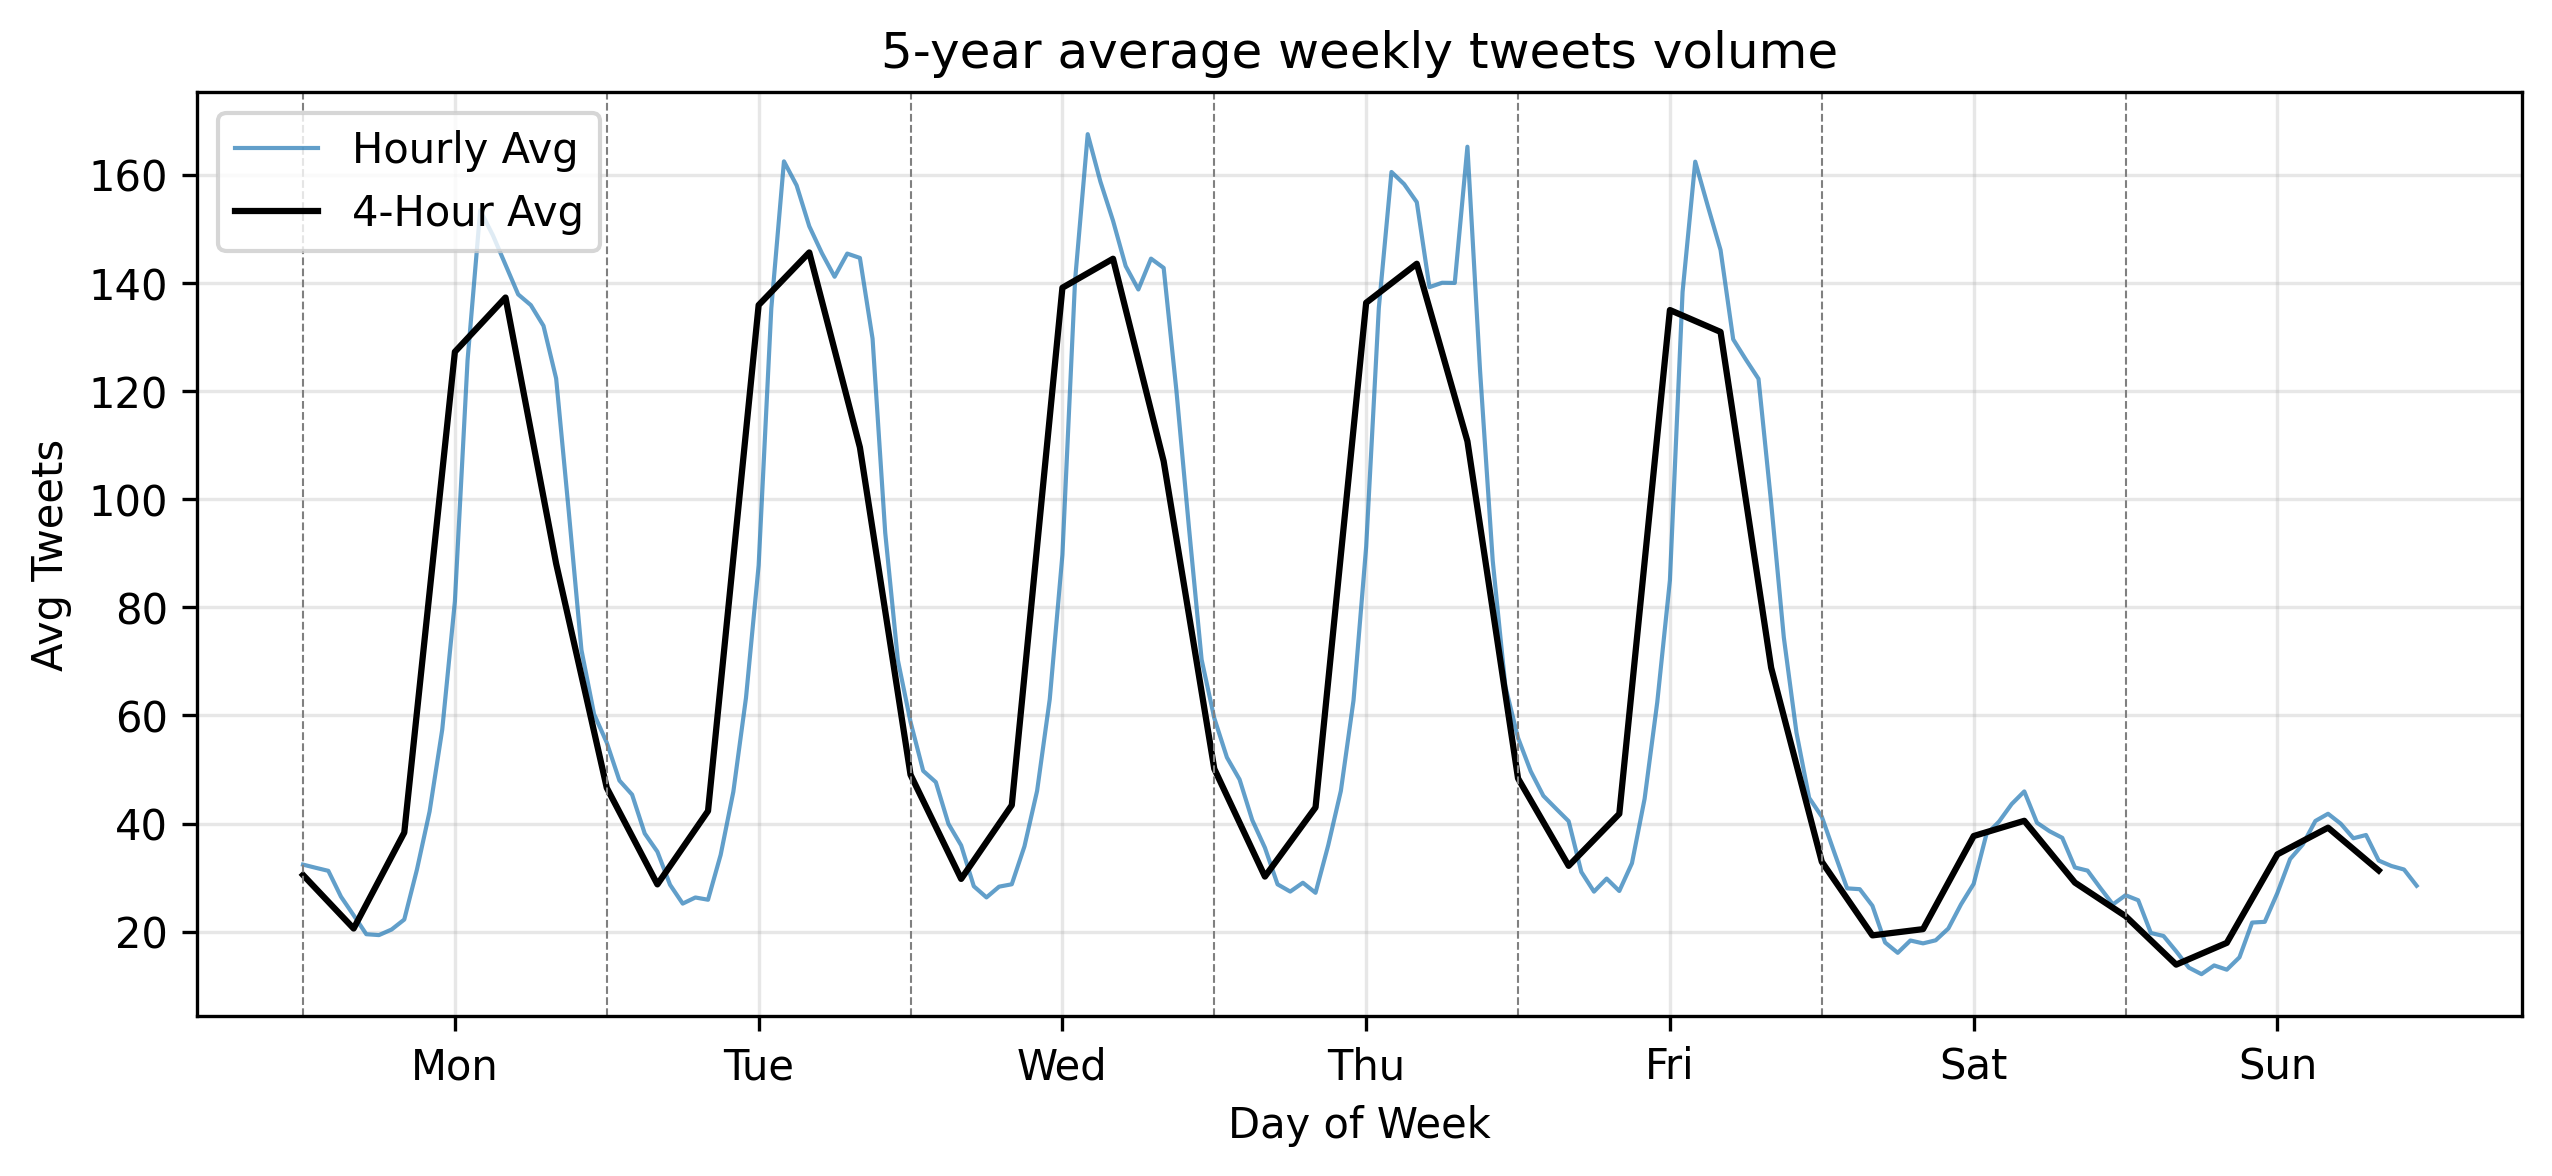

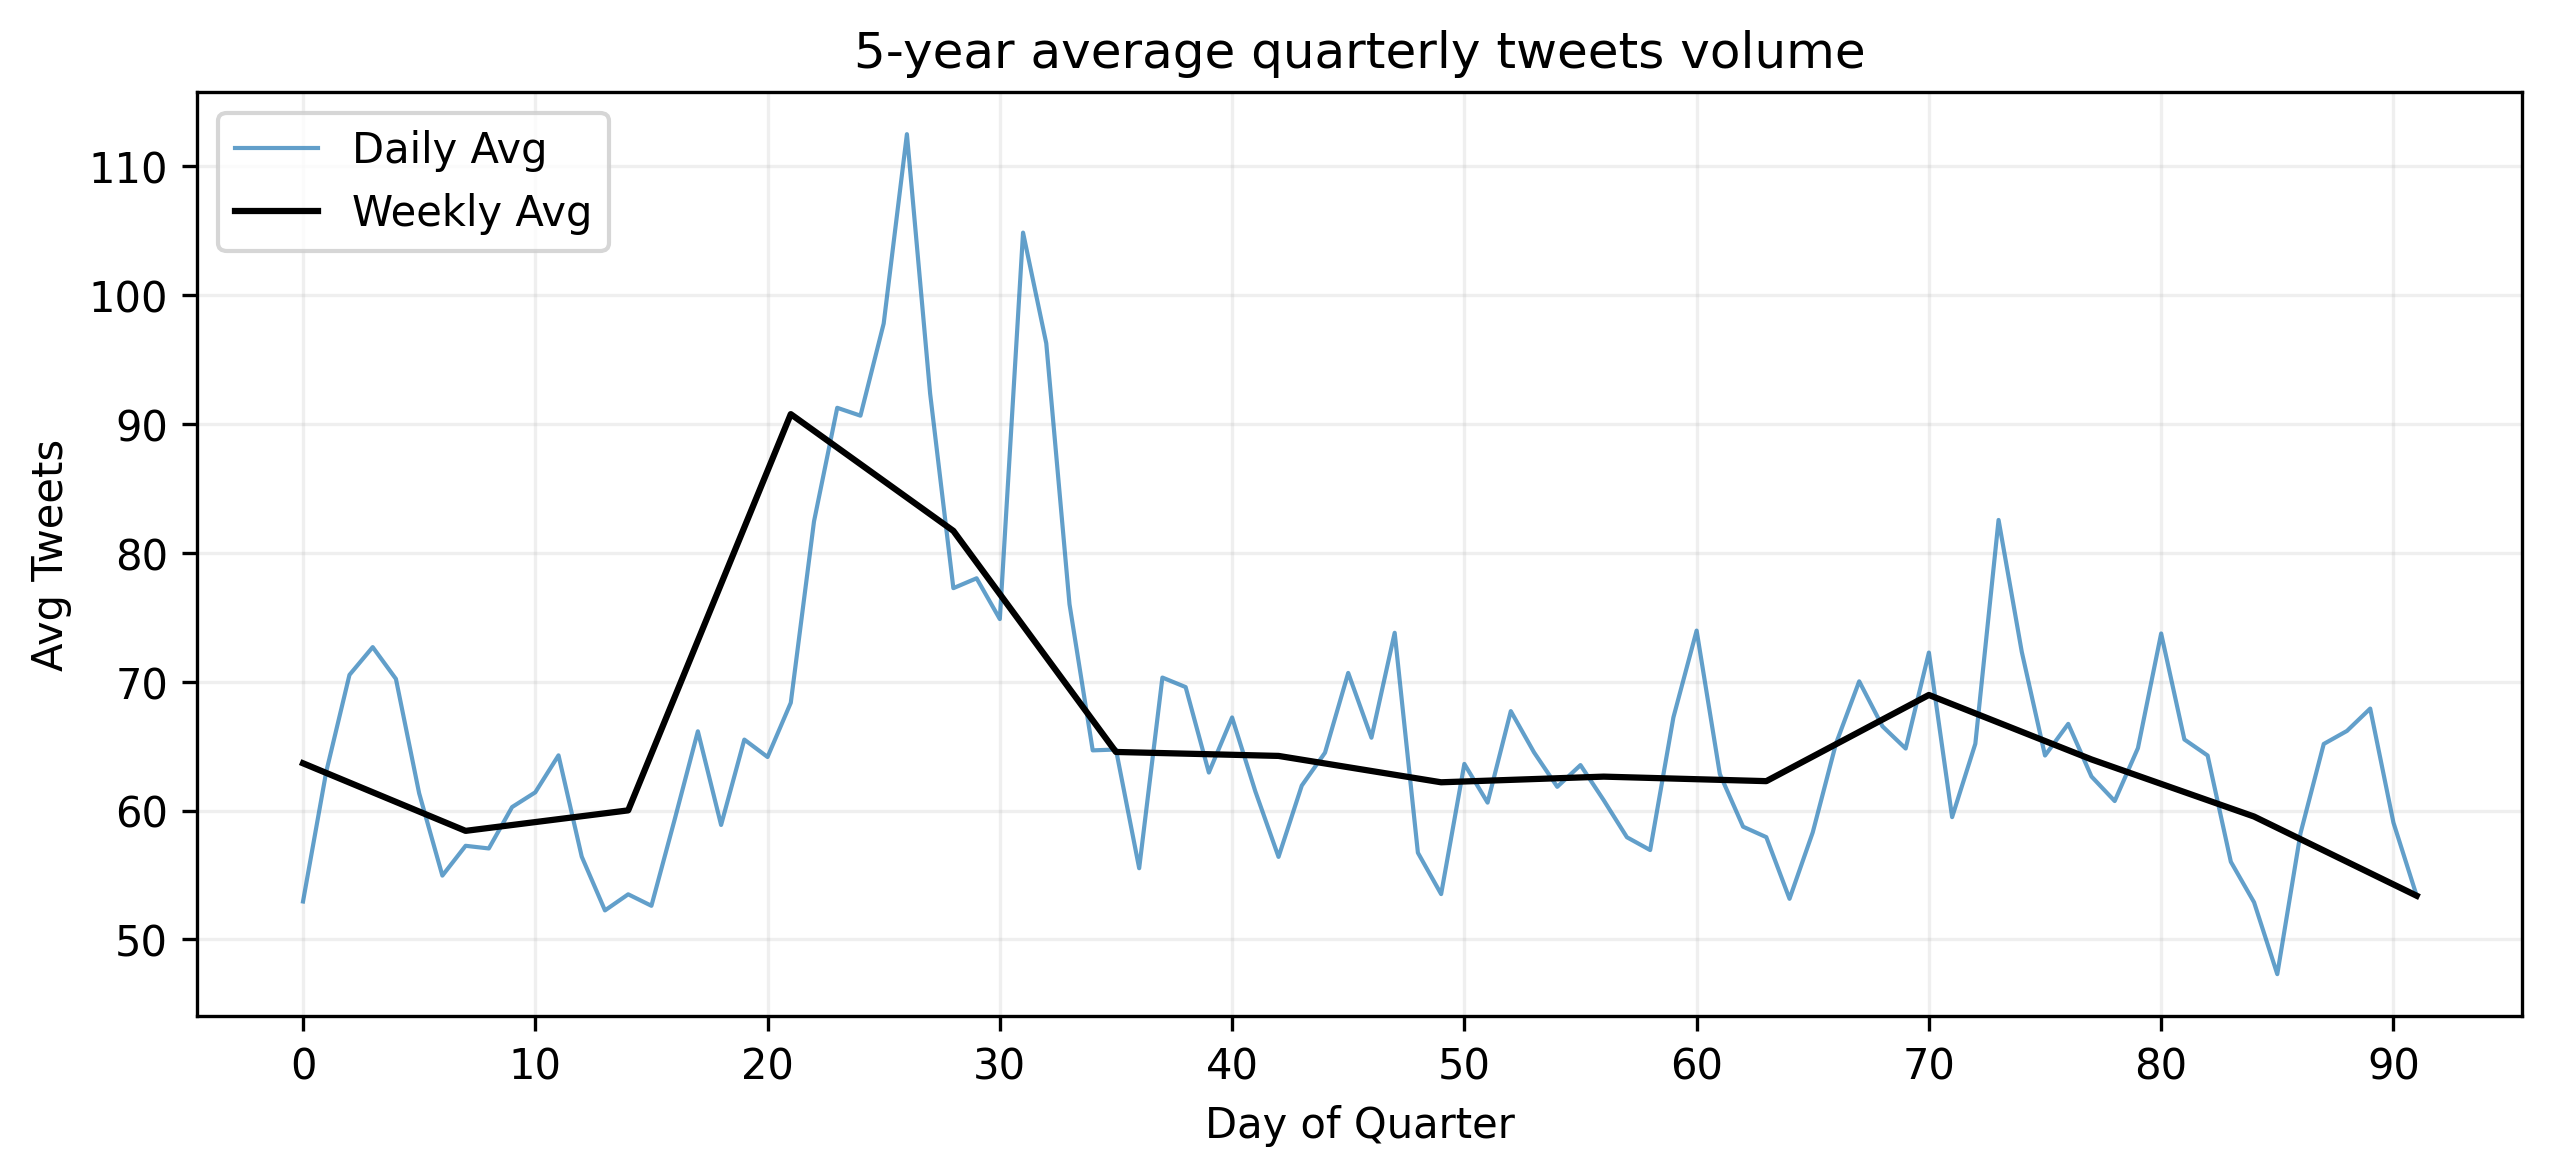

In [ ]:
import numpy as np

### DAILY
minute = dates.dt.hour * 60 + dates.dt.minute

plot_df = pd.DataFrame({'minute': minute,'ticker': df['ticker'].fillna('')})
avg_per_minute = plot_df.groupby('minute').size() / len(dates.dt.date.unique())

avg_per_10min = avg_per_minute.groupby(avg_per_minute.index // 10).mean()
x_10min = np.arange(0, 1440, 10)

avg_per_hour = avg_per_minute.groupby(avg_per_minute.index // 60).mean()
x_hour = np.arange(0, 1440, 60)

plt.figure(figsize=(10, 4), dpi=300)

#avg_per_minute.plot(alpha=0.8, linewidth=0.7, label="1-min avg")
plt.plot(x_10min, avg_per_10min.values, label="10-min avg", alpha=0.7, linewidth=1)
plt.plot(x_hour, avg_per_hour.values, label="Hourly avg", linewidth=1.5, color='black')

# Market open/close
plt.axvline(x=570, color='red', linestyle='--', linewidth=0.8, label='mkt Open (9:30 AM)')
plt.axvline(x=960, color='red', linestyle='--', linewidth=0.8, label='mkt Close (4:00 PM)')

# Pre-market
plt.axvline(x=240, linestyle='--', linewidth=0.8, label='Pre-mkt (4:00 AM)')
plt.axvline(x=1200, linestyle='--', linewidth=0.8, label='After-hours (8:00 PM)')

plt.title("5-year average daily tweets volume")
plt.xlabel("Time of day")
plt.ylabel("Avg Tweets")
plt.grid(alpha=0.3)
plt.legend(loc='upper left')
plt.show()


### WEEKLY
# Compute hour of the week (0 to 167)
hour_of_week = dates.dt.dayofweek * 24 + dates.dt.hour

plot_df_weekly = pd.DataFrame({'hour_week': hour_of_week})
num_weeks = dates.dt.to_period('W').nunique()

avg_per_hour_weekly = plot_df_weekly.groupby('hour_week').size() / num_weeks
avg_per_4h_weekly = avg_per_hour_weekly.groupby(avg_per_hour_weekly.index // 4).mean()
x_4h = np.arange(0, 168, 4)

# Plotting
plt.figure(figsize=(10, 4), dpi=300)

avg_per_hour_weekly.plot(alpha=0.7, linewidth=1, label="Hourly Avg")
plt.plot(x_4h, avg_per_4h_weekly.values, label="4-Hour Avg", linewidth=1.5, color='black')


days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
for i in range(7):
    plt.axvline(x=i*24, color='gray', linestyle='--', linewidth=0.5)
plt.xticks(np.arange(12, 168, 24), days)

plt.title("5-year average weekly tweets volume")
plt.xlabel("Day of Week")
plt.ylabel("Avg Tweets")
plt.grid(alpha=0.3)
plt.legend(loc='upper left')
plt.show()


#### MONTHLY
#hour_of_month = (dates.dt.day - 1) * 24 + dates.dt.hour
#year_month = dates.dt.to_period('M')
#df_monthly = pd.DataFrame({'hour_month': hour_of_month, 'year_month': year_month})
#
## Dynamic denominator calculation per hour bucket
#counts_per_hour = df_monthly.groupby('hour_month').size()
#denoms_per_hour = df_monthly.groupby('hour_month')['year_month'].nunique()
#avg_per_hour_monthly = counts_per_hour / denoms_per_hour
#
#
#avg_per_day_monthly = avg_per_hour_monthly.groupby(avg_per_hour_monthly.index // 24).mean()
#x_day_monthly = np.arange(0, len(avg_per_hour_monthly), 24)
#
## Plotting
#plt.figure(figsize=(10, 4), dpi=300)
#avg_per_hour_monthly.plot(alpha=0.7, linewidth=1, label="Hourly Avg")
#plt.plot(x_day_monthly, avg_per_day_monthly.values, label="Daily Avg", color='black', linewidth=1.5)
#
#plt.title("5-year average monthly tweets volume")
#plt.xlabel("Day of Month")
#plt.ylabel("Avg Tweets")
#plt.xticks(np.arange(0, 31*24, 24*5), np.arange(1, 32, 5))
#plt.grid(alpha=0.3)
#plt.legend(loc='upper left')
#plt.show()


### QUARTERLY
# Compute delta days from the start of the specific administrative quarter
quarter_start = dates.dt.to_period('Q').dt.to_timestamp()
day_of_quarter = (dates - quarter_start).dt.days

# Compute hour of quarter
hour_of_quarter = day_of_quarter * 24 + dates.dt.hour
year_quarter = dates.dt.to_period('Q')

df_quarterly = pd.DataFrame({'hour_quarter': hour_of_quarter, 'year_quarter': year_quarter})

# Dynamic denominator calculation per hour bucket
counts_per_q_hour = df_quarterly.groupby('hour_quarter').size()
denoms_per_q_hour = df_quarterly.groupby('hour_quarter')['year_quarter'].nunique()
avg_per_hour_quarterly = counts_per_q_hour / denoms_per_q_hour

# Rolling smoothings (Daily and Weekly)
avg_per_day_q = avg_per_hour_quarterly.groupby(avg_per_hour_quarterly.index // 24).mean()
x_day_q = np.arange(0, len(avg_per_hour_quarterly), 24)

avg_per_week_q = avg_per_hour_quarterly.groupby(avg_per_hour_quarterly.index // (24 * 7)).mean()
x_week_q = np.arange(0, len(avg_per_hour_quarterly), 24 * 7)

# Plotting
plt.figure(figsize=(10, 4), dpi=300)
plt.plot(x_day_q, avg_per_day_q.values, alpha=0.7, linewidth=1, label="Daily Avg")
plt.plot(x_week_q, avg_per_week_q.values, color='black', linewidth=1.5, label="Weekly Avg")

plt.title("5-year average quarterly tweets volume")
plt.xlabel("Day of Quarter")
plt.ylabel("Avg Tweets")
plt.xticks(np.arange(0, 92*24, 24*10), np.arange(0, 92, 10))
plt.grid(alpha=0.2)
plt.legend(loc='upper left')
plt.show()


#### YEARLY
#year_start = dates.dt.to_period('Y').dt.to_timestamp()
#day_of_year = (dates - year_start).dt.days
#
## Compute hour of year
#hour_of_year = day_of_year * 24 + dates.dt.hour
#year_period = dates.dt.to_period('Y')
#
#df_yearly = pd.DataFrame({'hour_year': hour_of_year, 'year_period': year_period})
#
## Dynamic denominator calculation per hour bucket (safely isolates leap year day 366)
#counts_per_y_hour = df_yearly.groupby('hour_year').size()
#denoms_per_y_hour = df_yearly.groupby('hour_year')['year_period'].nunique()
#avg_per_hour_yearly = counts_per_y_hour / denoms_per_y_hour
#
## Rolling smoothings (Daily and Weekly)
#avg_per_day_y = avg_per_hour_yearly.groupby(avg_per_hour_yearly.index // 24).mean()
#x_day_y = np.arange(0, len(avg_per_hour_yearly), 24)
#
#avg_per_week_y = avg_per_hour_yearly.groupby(avg_per_hour_yearly.index // (24 * 7)).mean()
#x_week_y = np.arange(0, len(avg_per_hour_yearly), 24 * 7)
#
## Plotting
#plt.figure(figsize=(10, 4), dpi=300)
#plt.plot(x_day_y, avg_per_day_y.values, alpha=0.7, linewidth=1, label="Daily Avg")
#plt.plot(x_week_y, avg_per_week_y.values, color='black', linewidth=1.5, label="Weekly Avg")
#
#plt.title("5-Year Average Tweet Volume Across an Administrative Year")
#plt.xlabel("Day of Year")
#plt.ylabel("Avg Tweets")
#plt.xticks(np.arange(0, 366*24, 24*30), np.arange(0, 366, 30))
#plt.grid(alpha=0.2)
#plt.legend(loc='upper left')
#plt.show()

AI NOTE

On a standard 90-day administrative quarter scale, the volume distribution follows this specific timeline:
Days 1 – 14: Quiet period. Very few macro-cap companies report. Data aggregation phase.
Days 15 – 45 (Peak Earnings Season): The highest concentration of announcements. This 3-week window (roughly weeks 3 through 6 of the calendar quarter) contains over 70% of S&P 500 earnings releases. You will see the primary volume spikes here.
Days 46 – 60: Tail-end period. Mid-cap and small-cap companies finish reporting. Volume begins to taper off.
Days 61 – 90: Dead zone. Virtually zero earnings activity for standard fiscal-year companies.

We use FinBERT, a pre-trained NLP model, to analyse the sentiment of 3M tweets. FinBERT is built by further training on financial data of the BERT language model developed by Google. 


We load the model from ProsusAI/finbert on Hugging Face.

In [7]:
from transformers import pipeline
import torch

classifier = pipeline(
    "text-classification", 
    model="ProsusAI/finbert", 
    device=torch.device("mps"), # Apple Silicon M2 GPU
    #dtype=torch.float16, 
    batch_size=512 # 16go RAM
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 21972.30it/s]


In [9]:
from tqdm import tqdm

begin = 0
to = 100

df_slice = df.iloc[begin:to].copy()
tweets = df_slice['body'].fillna("").tolist()

results = []

for tweet in tqdm(tweets, desc="FinBERT"):
    out = classifier(tweet)[0]  
    results.append({
        'label': out['label'],
        'score': out['score']
    })

df_results = pd.DataFrame(results, index=df_slice.index)  
df_slice = pd.concat([df_slice, df_results], axis=1)

df_slice.to_csv(f"data/output/finBERT_{begin}_to_{to}.csv", index=True)

df.head()

FinBERT: 100%|██████████| 100/100 [00:02<00:00, 35.91it/s]


,tweet_id,writer,post_date,body,comment_num,retweet_num,like_num,ticker_symbol
0,550441672312512512,KeralaGuy77,1420070496,Insanity of today weirdo massive selling. $aap...,0,0,0,AAPL
1,550442977802207232,ShowDreamCar,1420070807,$GM $TSLA: Volkswagen Pushes 2014 Record Recal...,0,0,1,TSLA
2,550444969924653056,AppleNewsAAPL,1420071282,$AAPL Apple goes global with 'Start Something ...,0,0,1,AAPL
3,550444970738335744,espositooooo,1420071282,“@WSJ: Apple is being sued for falsely adverti...,0,0,0,AAPL
4,550445066444369921,Bidnessetc,1420071305,Apple filed for its own stylus patent in 2010 ...,0,0,0,AAPL


# **Sentiment description**

- distribution global des sentiments (pie shart totale et par firm)
- daily average sentiment score, per day, over the full period, en per firm (positive/negative)
- positive ratio: proportion of positive sentiment comments to all comments, per day, over the full period
- emotion intensity: difference in the number of positive and negative sentiment reviews, per day, over the entire period
- emotion volatility: SD of sentiment scores, per day, over the entire period
- non-trading hours sentiment bias: difference between sentuiment indicators during non-trading hours and during-trading hours: used to sutdy the effect of pre-post market sentiment




We first load our data and prepare our daily sentiment metric.

In [ ]:
finBERT1 = pd.read_csv("data/output/finBERT_0_to_2000000.csv")
finBERT2 = pd.read_csv("data/output/finBERT_2000000_to_2906577.csv")
df = pd.concat([finBERT1, finBERT2], ignore_index=True)
df['date'] = pd.to_datetime(df['post_date'], unit='s').dt.date

# Mapping: positive = +1, negative = -1, neutral = 0
sentiment_map = {'positive': 1, 'negative': -1, 'neutral': 0}
df['sentiment_value'] = df['label'].map(sentiment_map)

# Daily global sentiment
daily_global = (
    df.groupby('date')['sentiment_value']
    .mean()
    .reset_index(name='sentiment_score')
)
daily_global['date'] = pd.to_datetime(daily_global['date'])

# Daily firm sentiment
df_exploded = df.copy()
df_exploded['ticker'] = df_exploded['ticker'].str.split(', ')
df_exploded = df_exploded.explode('ticker')
df_exploded['ticker'] = df_exploded['ticker'].str.strip()

daily_per_firm = (
    df_exploded.groupby(['date', 'ticker'])['sentiment_value']
    .mean()
    .reset_index(name='sentiment_score')
)
daily_per_firm['date'] = pd.to_datetime(daily_per_firm['date'])

We then plot these daily results. We can weight them using likes/RT/comments.

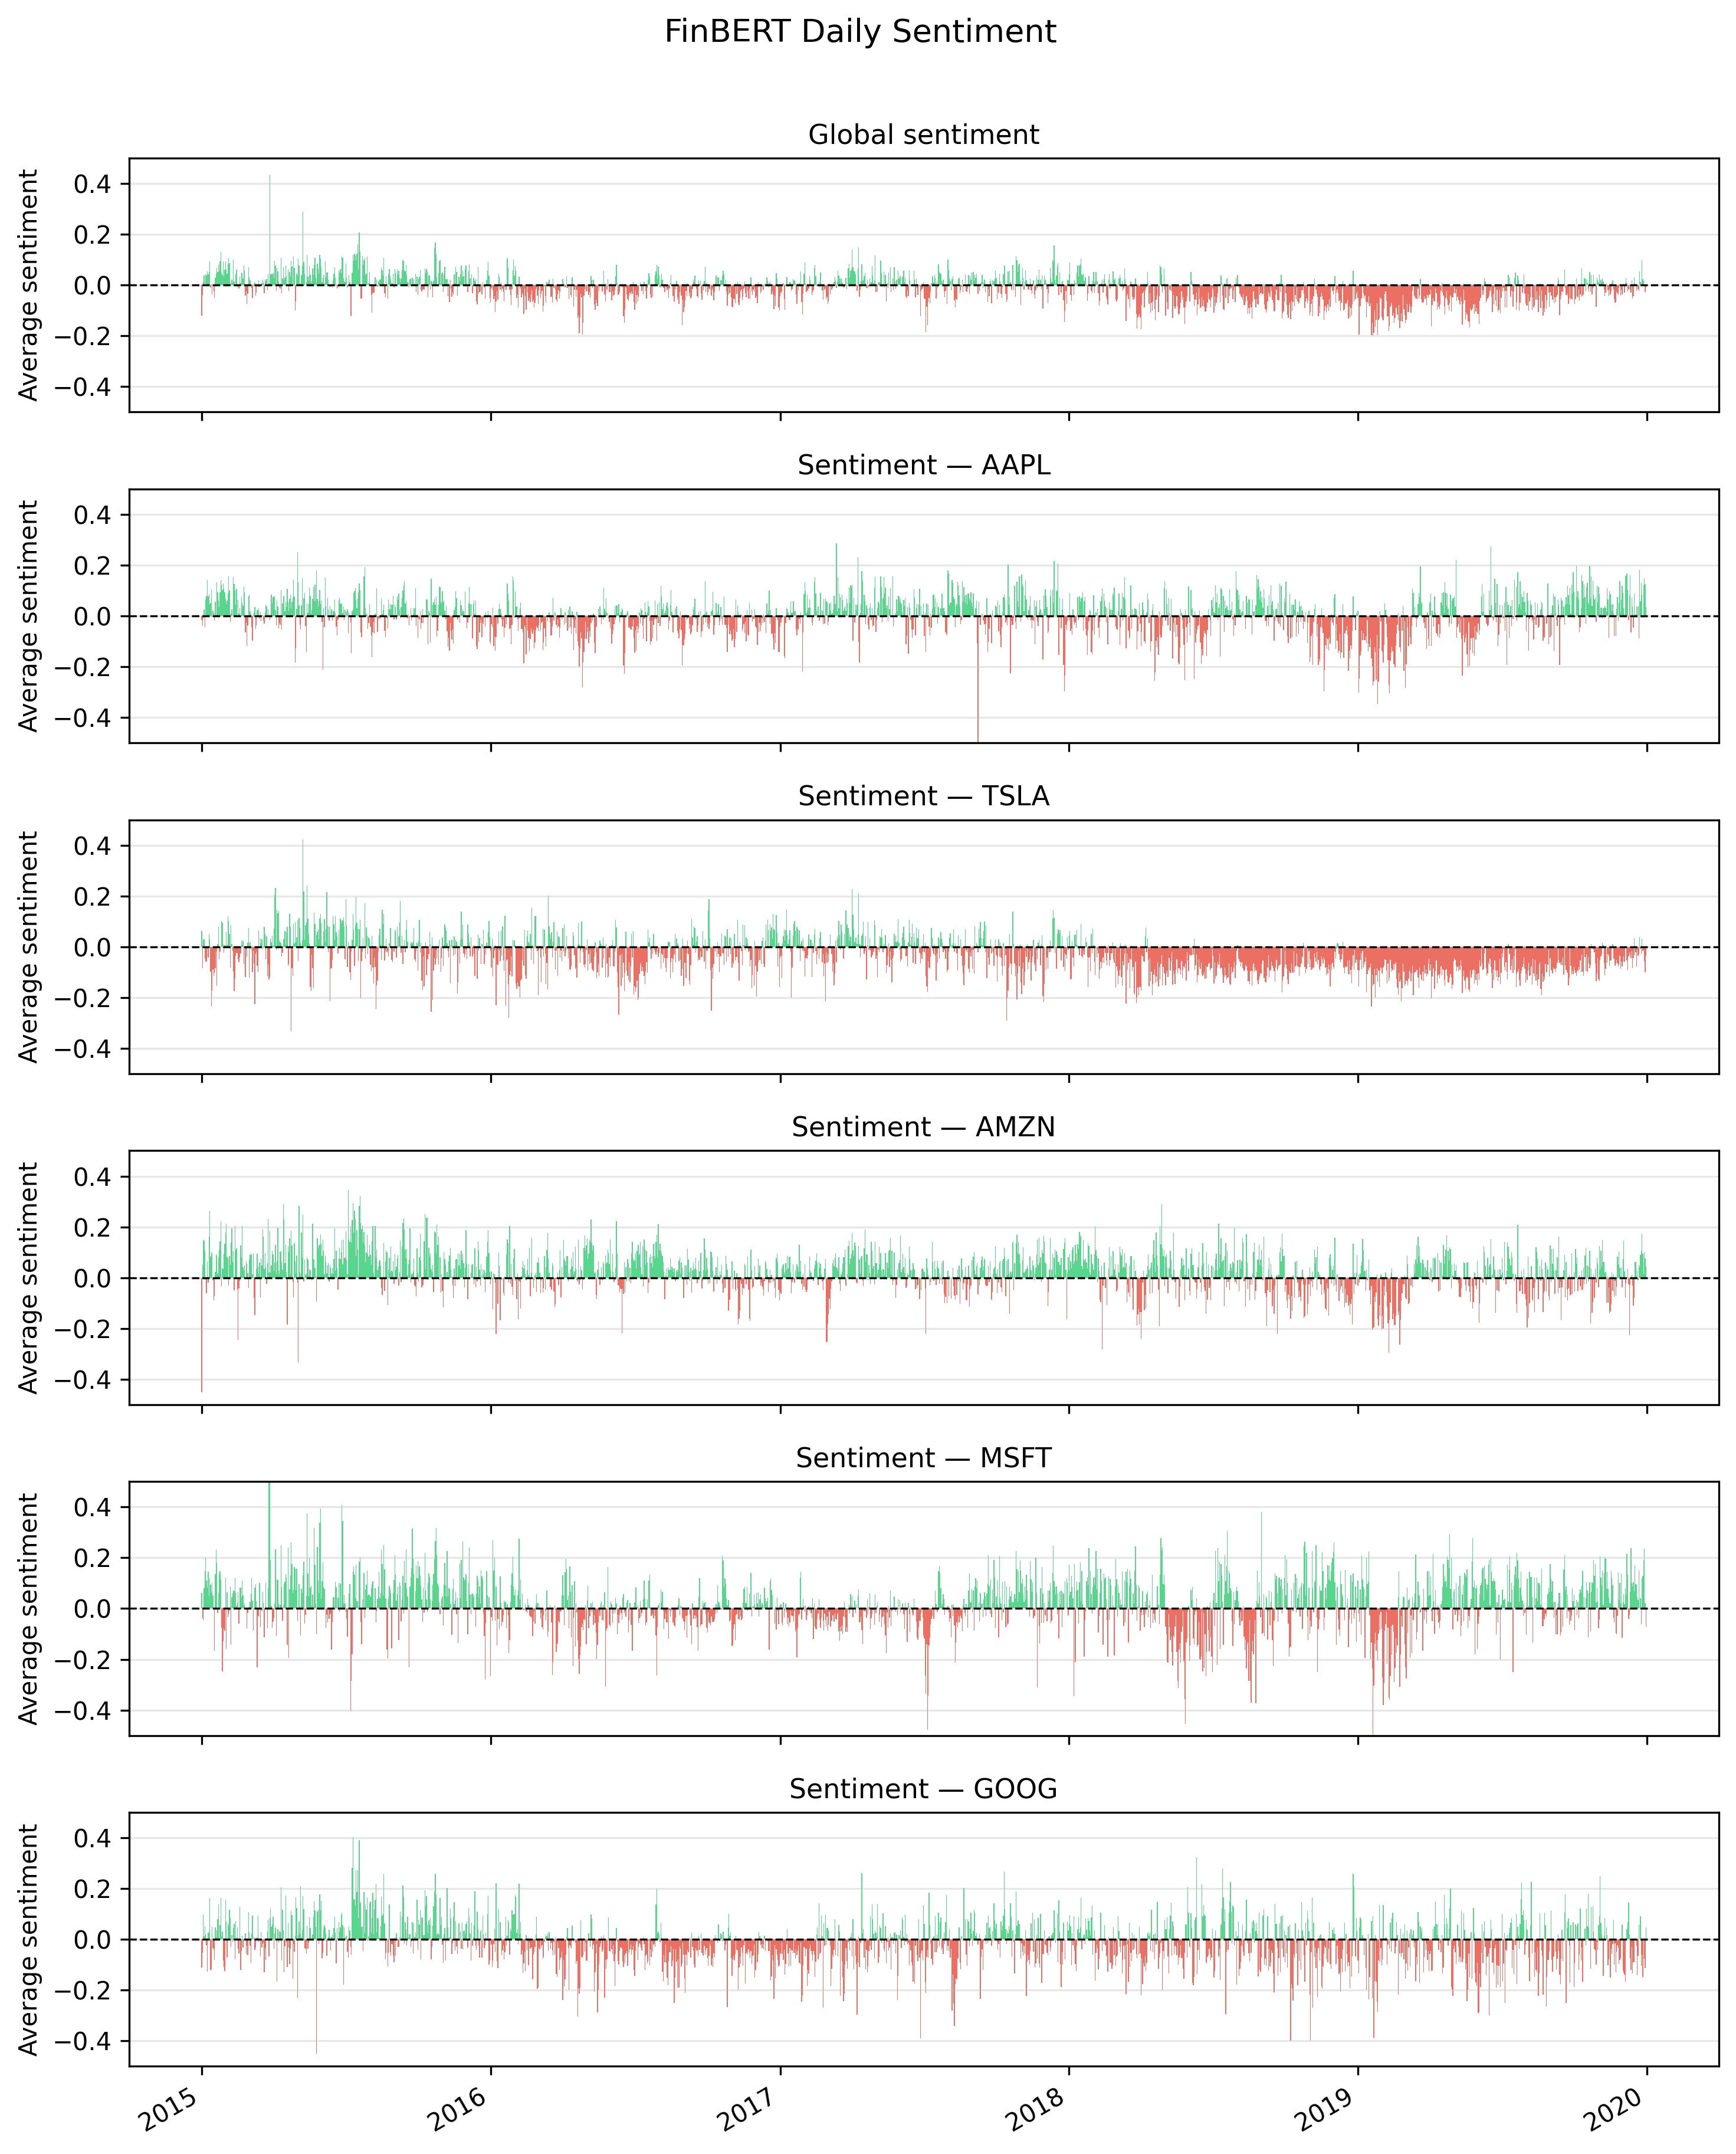

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

firms = ['AAPL', 'TSLA', 'AMZN', 'MSFT', 'GOOG']  # ← modifie selon tes besoins

n_plots = 1 + len(firms)
fig, axes = plt.subplots(n_plots, 1, figsize=(10, 2 * n_plots), sharex=True, dpi=300)

all_data = [("Global sentiment", daily_global)] + [
    (f"Sentiment — {f}", daily_per_firm[daily_per_firm['ticker'] == f].sort_values('date'))
    for f in firms
]

for ax, (title, data) in zip(axes, all_data):
    colors = ['#e74c3c' if s < 0 else '#2ecc71' for s in data['sentiment_score']]

    ax.bar(data['date'], data['sentiment_score'], color=colors, width=1, alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')

    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Average sentiment")
    ax.set_ylim(-0.5, 0.5)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.grid(axis='y', alpha=0.3)

fig.autofmt_xdate(rotation=30)
plt.suptitle("FinBERT Daily Sentiment", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()